# UK Property Price Prediction
## LSBU SSE CW2 - England Property ML / DL Pipeline

**Dataset:** HM Land Registry + EPC + ONSPD enriched (~5 M rows, 2018-2024)  
**Models:** LightGBM benchmark (3000 rounds) + Deep Learning Entity Embeddings (PyTorch)  
**Target:** log_sale_price = log1p(sale_price) -- predictions back-transformed to GBP

---

| Step | Description |
|------|-------------|
| 1 | Imports and configuration |
| 2 | Data loading |
| 3 | Exploratory Data Analysis |
| 4 | Data cleaning |
| 5 | Feature engineering |
| 6 | Outlier analysis and handling |
| 7 | Feature encoding |
| 8 | Time-based train/val/test split |
| 9 | LightGBM model |
| 10 | Deep Learning model |
| 11 | Model comparison |


## 1  Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings, os, time, math
warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:,.2f}".format)
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 110
print("Core imports OK")


Core imports OK


In [2]:
import torch
print(torch.__version__)
print("CUDA avail:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0))

2.11.0+cu126
CUDA avail: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


In [3]:
import lightgbm as lgb
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeRegressor
import joblib
print(f"LightGBM  {lgb.__version__}")
print(f"PyTorch   {torch.__version__}")
print(f"CUDA avail: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")


LightGBM  4.6.0
PyTorch   2.11.0+cu126
CUDA avail: True
GPU: NVIDIA GeForce RTX 4090 Laptop GPU


In [4]:
# Paths
BASE_DIR  = os.path.dirname(os.path.abspath("__file__"))
DATA_PATH = os.path.join(BASE_DIR, "dataset.csv")
MODEL_LGB = os.path.join(BASE_DIR, "model_lgb")
MODEL_DL  = os.path.join(BASE_DIR, "model_dl")
os.makedirs(MODEL_LGB, exist_ok=True)
os.makedirs(MODEL_DL,  exist_ok=True)
# Feature groups
CATEGORICAL_COLS = ["property_type","tenure_type","construction_age_band",
                    "region_code","local_authority_code","postcode_district",
                    "sale_month"]
NUMERIC_COLS = ["is_new_build","floor_area_sqm","room_count",
                "room_count_was_imputed","current_epc_score",
                "latitude","longitude","imd_value",
                "distance_to_nearest_school_miles",
                "distance_to_nearest_station_miles",
                "distance_to_nearest_park_miles",
                "bank_rate_at_sale_pct","unemployment_rate_at_sale_pct",
                "sale_year"]
TARGET_COL   = "log_sale_price"
FEATURE_COLS = NUMERIC_COLS + CATEGORICAL_COLS
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE} | Dirs: model_lgb/, model_dl/ created")


Device: cuda | Dirs: model_lgb/, model_dl/ created


## 2  Data Loading

The file  (~1.7 GB) contains enriched UK property transactions:
- **HM Land Registry** -- sale price, property type, tenure, address
- **EPC** -- floor area, room count, EPC score, construction age band
- **ONSPD** -- region, local authority, lat/lon, IMD, distances
- **Macro indicators** -- Bank of England base rate, unemployment rate


In [5]:
t0 = time.time()
df = pd.read_csv(DATA_PATH, low_memory=False)
print(f"Loaded {len(df):,} rows x {df.shape[1]} cols in {time.time()-t0:.1f}s")
print(f"Memory: {df.memory_usage(deep=True).sum()/1e9:.2f} GB")
df.head(3)


Loaded 5,019,426 rows x 33 cols in 22.4s
Memory: 5.81 GB


,transaction_id,price_hm,date_of_transfer,year,postcode_hm,postcode_nospace_hm,full_address,property_type,old_new,duration_hm,...,nearest_school_name,nearest_school_miles,nearest_station_name,nearest_station_miles,nearest_park_name,nearest_park_miles,bank_rate_at_sale,bank_rate_effective_date,unemployment_rate_at_sale,unemployment_reference_date
0,{64342BFE-F64C-422C-E053-6C04A8C0FB8A},172500,2018-01-01,2018,SR3 2RN,SR32RN,4 MIDSOMER CLOSE SUNDERLAND SR3 2RN,S,N,L,...,Benedict Biscop Church of England Academy,0.10,South Hylton (Tyne and Wear Metro Station),2.98,Sunderland Health and Racquets Club,0.21,0.50,2017-11-02,4.30,2017-12-31
1,{666758D6-B6E3-3363-E053-6B04A8C0D74E},190000,2018-01-01,2018,S40 3AL,S403AL,20 RHODESIA ROAD CHESTERFIELD S40 3AL,S,N,F,...,Old Hall Junior School,0.20,Chesterfield Rail Station,1.69,West Ward Allotments,0.02,0.50,2017-11-02,4.30,2017-12-31
2,{64342BFE-C1B7-422C-E053-6C04A8C0FB8A},335000,2018-01-01,2018,DA1 4PZ,DA14PZ,40 MAYPLACE AVENUE CRAYFORD DARTFORD DA1 4PZ,S,N,F,...,Haberdashers' Crayford Primary,0.12,Slade Green,0.70,Crayford Way Allotments,0.22,0.50,2017-11-02,4.30,2017-12-31


In [6]:
# Column rename + derivation -- normalises raw CSV names to notebook names
RENAME_MAP = {
    "price_hm"                 : "sale_price",
    "date_of_transfer"         : "sale_date",
    "year"                     : "sale_year",
    "tfarea"                   : "floor_area_sqm",
    "numberrooms"              : "room_count",
    "CONSTRUCTION_AGE_BAND"    : "construction_age_band",
    "CURRENT_ENERGY_EFFICIENCY": "current_epc_score",
    "rgn"                      : "region_code",
    "oslaua"                   : "local_authority_code",
    "imd"                      : "imd_value",
    "lat"                      : "latitude",
    "long"                     : "longitude",
    "nearest_school_miles"     : "distance_to_nearest_school_miles",
    "nearest_station_miles"    : "distance_to_nearest_station_miles",
    "nearest_park_miles"       : "distance_to_nearest_park_miles",
    "bank_rate_at_sale"        : "bank_rate_at_sale_pct",
    "unemployment_rate_at_sale": "unemployment_rate_at_sale_pct",
    "duration_hm"              : "tenure_type",
}
df.rename(columns={k: v for k, v in RENAME_MAP.items()
                   if k in df.columns}, inplace=True)
# is_new_build: N=new build->1, Y=old->0
df["is_new_build"] = (df["old_new"] == "N").astype(int)
# postcode_district: first part of postcode ("SW1A 1AA" -> "SW1A")
df["postcode_district"] = df["postcode_hm"].str.split(" ").str[0].fillna("Unknown")
# sale_month from sale_date (if not already present)
if "sale_month" not in df.columns:
    df["sale_month"] = pd.to_datetime(df["sale_date"], errors="coerce").dt.month.fillna(1).astype(int)
print("Column rename complete. Key columns present:",
      [c for c in ["sale_price","floor_area_sqm","room_count","construction_age_band",
                   "current_epc_score","region_code","local_authority_code",
                   "postcode_district","is_new_build","tenure_type"] if c in df.columns])


Column rename complete. Key columns present: ['sale_price', 'floor_area_sqm', 'room_count', 'construction_age_band', 'current_epc_score', 'region_code', 'local_authority_code', 'postcode_district', 'is_new_build', 'tenure_type']


In [7]:
# Column types and null summary
info = pd.DataFrame({
    "dtype"   : df.dtypes,
    "non_null": df.notna().sum(),
    "null_pct": (df.isna().mean() * 100).round(2)
})
print(info.to_string())


                                     dtype  non_null  null_pct
transaction_id                      object   5019426      0.00
sale_price                           int64   5019426      0.00
sale_date                           object   5019426      0.00
sale_year                            int64   5019426      0.00
postcode_hm                         object   5019426      0.00
postcode_nospace_hm                 object   5019426      0.00
full_address                        object   5019426      0.00
property_type                       object   5019426      0.00
old_new                             object   5019426      0.00
tenure_type                         object   5019426      0.00
floor_area_sqm                     float64   5019426      0.00
room_count                         float64   4056164     19.19
classt                               int64   5019426      0.00
current_epc_score                    int64   5019426      0.00
POTENTIAL_ENERGY_EFFICIENCY          int64   5019426   

In [8]:
# Numeric summary statistics
df.describe(include=[float, int]).T[
    ["count","mean","std","min","50%","max"]
].round(2)


,count,mean,std,min,50%,max
sale_price,"5,019,426.00","339,457.93","357,866.86",1.00,"270,000.00","68,250,000.00"
sale_year,"5,019,426.00","2,020.70",1.83,"2,018.00","2,021.00","2,024.00"
floor_area_sqm,"5,019,426.00",96.13,52.00,0.00,85.00,"41,082.74"
room_count,"4,056,164.00",4.68,1.66,1.00,5.00,99.00
classt,"5,019,426.00",11.19,0.39,11.00,11.00,12.00
current_epc_score,"5,019,426.00",65.89,13.68,1.00,67.00,248.00
POTENTIAL_ENERGY_EFFICIENCY,"5,019,426.00",81.87,8.91,1.00,83.00,248.00
oseast1m,"5,019,426.00","453,071.24","86,027.46","88,364.00","447,725.00","655,247.00"
osnrth1m,"5,019,426.00","275,657.69","128,624.67","8,478.00","261,187.00","654,826.00"
latitude,"5,019,426.00",52.37,1.16,49.90,52.24,55.79


## 3  Exploratory Data Analysis

Before any cleaning we visualise: missing-value patterns, target distribution,
property type and tenure breakdowns, regional/yearly volumes, and correlations.


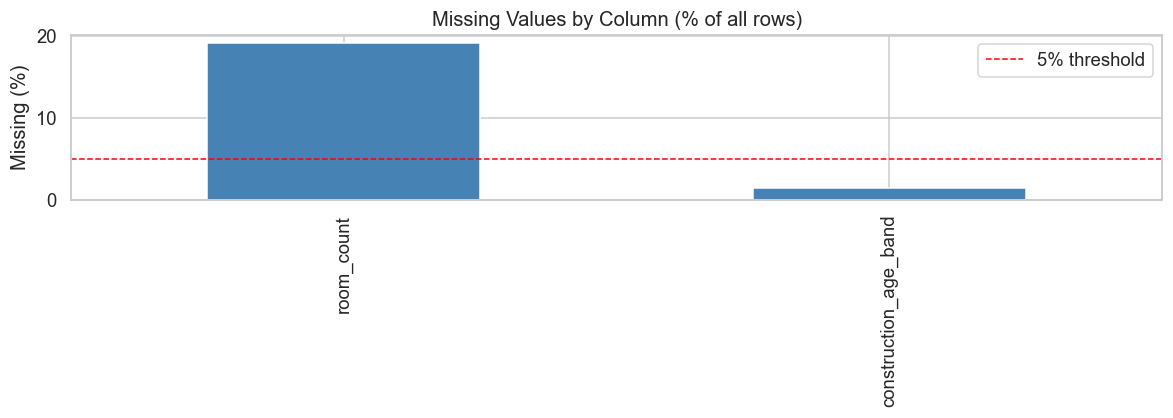

room_count              19.19
construction_age_band    1.43


In [9]:
# 3.1 Missing-value bar chart
miss = df.isnull().mean().mul(100).sort_values(ascending=False)
miss = miss[miss > 0]
fig, ax = plt.subplots(figsize=(11, 4))
miss.plot(kind="bar", ax=ax, color="steelblue", edgecolor="white")
ax.set_ylabel("Missing (%)")
ax.set_title("Missing Values by Column (% of all rows)")
ax.axhline(5, color="red", lw=1, ls="--", label="5% threshold")
ax.legend(); plt.tight_layout(); plt.show()
print(miss.round(2).to_string())


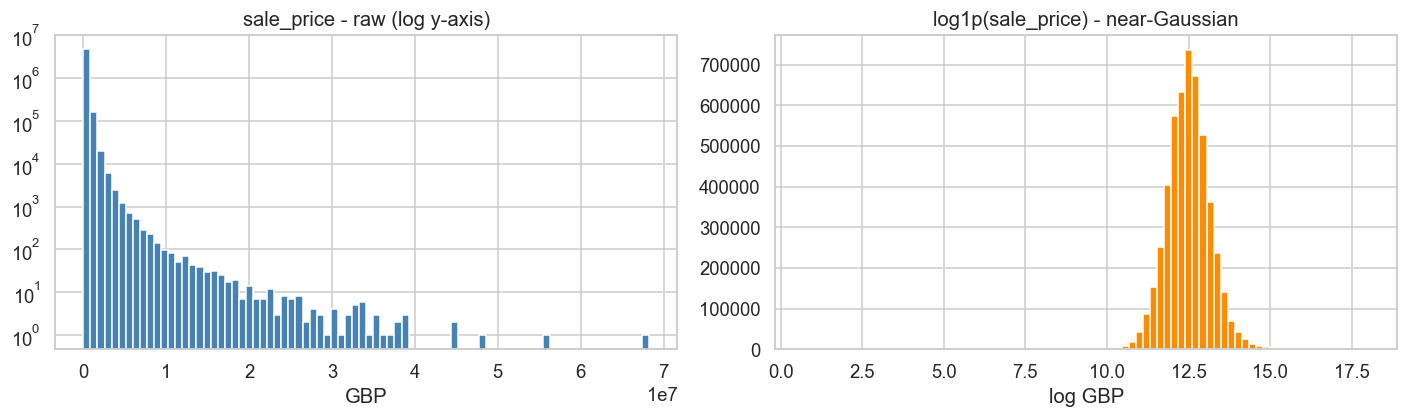

In [10]:
# 3.2 Target: raw vs log-transformed
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(df["sale_price"].dropna(), bins=80, color="steelblue", edgecolor="white", log=True)
axes[0].set_title("sale_price - raw (log y-axis)")
axes[0].set_xlabel("GBP")
axes[1].hist(np.log1p(df["sale_price"].dropna()), bins=80, color="darkorange", edgecolor="white")
axes[1].set_title("log1p(sale_price) - near-Gaussian")
axes[1].set_xlabel("log GBP")
plt.tight_layout(); plt.show()


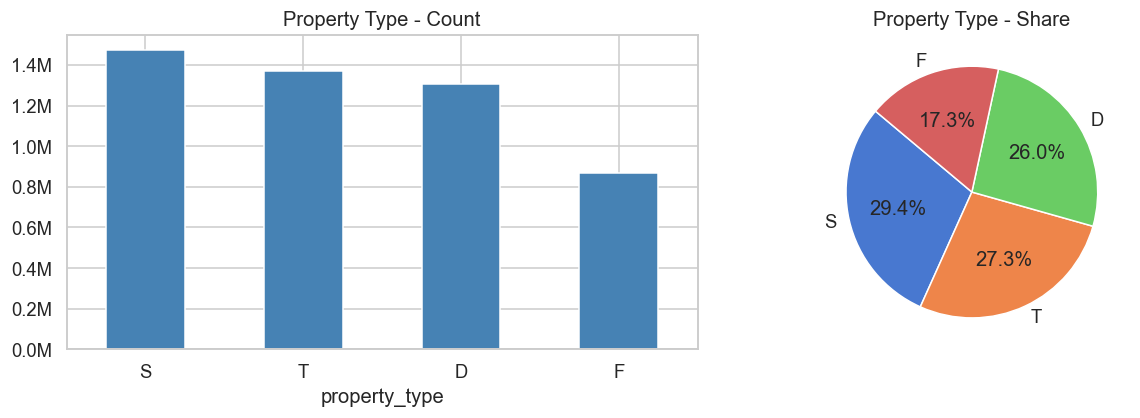

In [11]:
# 3.3 Property type - bar + pie
pt = df["property_type"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
pt.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="white", rot=0)
axes[0].set_title("Property Type - Count")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
axes[1].pie(pt, labels=pt.index, autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("muted", len(pt)))
axes[1].set_title("Property Type - Share")
plt.tight_layout(); plt.show()


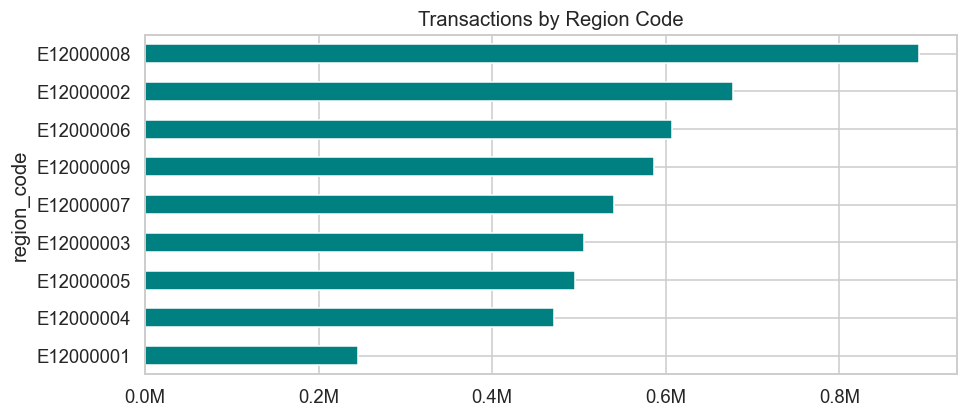

In [12]:
# 3.4 Region distribution
reg = df["region_code"].value_counts().sort_values()
fig, ax = plt.subplots(figsize=(9, 4))
reg.plot(kind="barh", ax=ax, color="teal", edgecolor="white")
ax.set_title("Transactions by Region Code")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
plt.tight_layout(); plt.show()


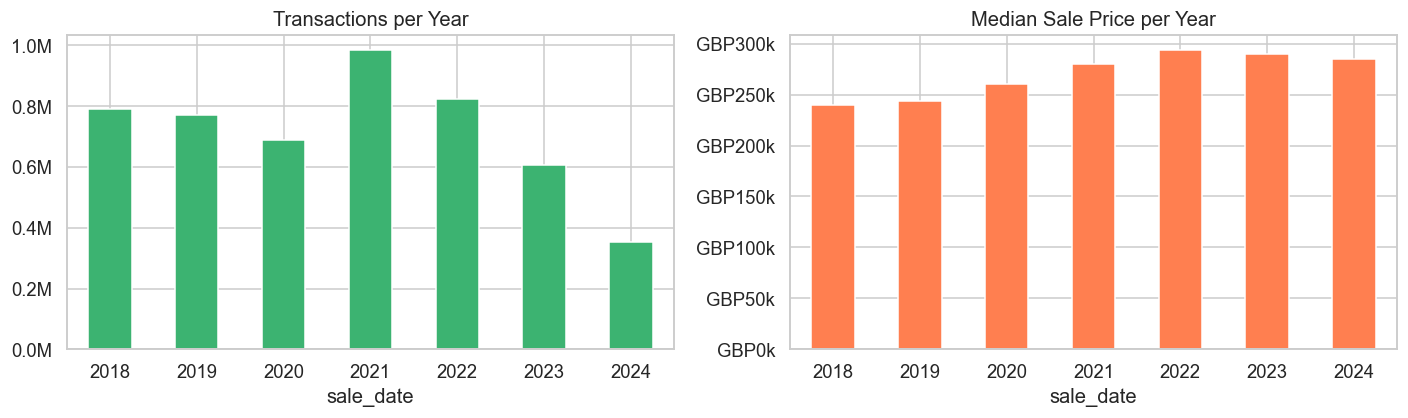

In [13]:
# 3.5 Transactions per year + median price
if "sale_date" in df.columns:
    yr = pd.to_datetime(df["sale_date"], errors="coerce").dt.year
elif "sale_year" in df.columns:
    yr = df["sale_year"]
else:
    yr = pd.Series([np.nan]*len(df))
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
yr.value_counts().sort_index().plot(kind="bar", ax=axes[0], color="mediumseagreen", edgecolor="white", rot=0)
axes[0].set_title("Transactions per Year")
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
df.groupby(yr)["sale_price"].median().plot(kind="bar", ax=axes[1], color="coral", edgecolor="white", rot=0)
axes[1].set_title("Median Sale Price per Year")
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"GBP{x/1e3:.0f}k"))
plt.tight_layout(); plt.show()


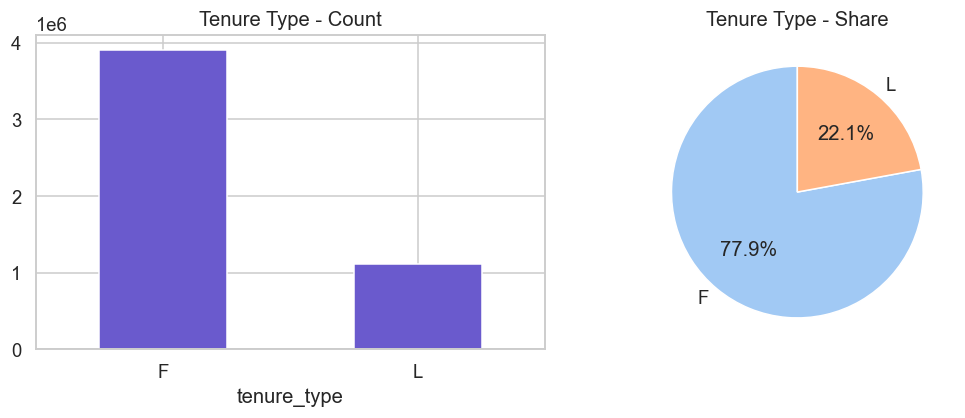

In [14]:
# 3.6 Tenure type - bar + pie
ten = df["tenure_type"].value_counts()
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ten.plot(kind="bar", ax=axes[0], color="slateblue", edgecolor="white", rot=0)
axes[0].set_title("Tenure Type - Count")
axes[1].pie(ten, labels=ten.index, autopct="%1.1f%%", startangle=90,
            colors=sns.color_palette("pastel", len(ten)))
axes[1].set_title("Tenure Type - Share")
plt.tight_layout(); plt.show()


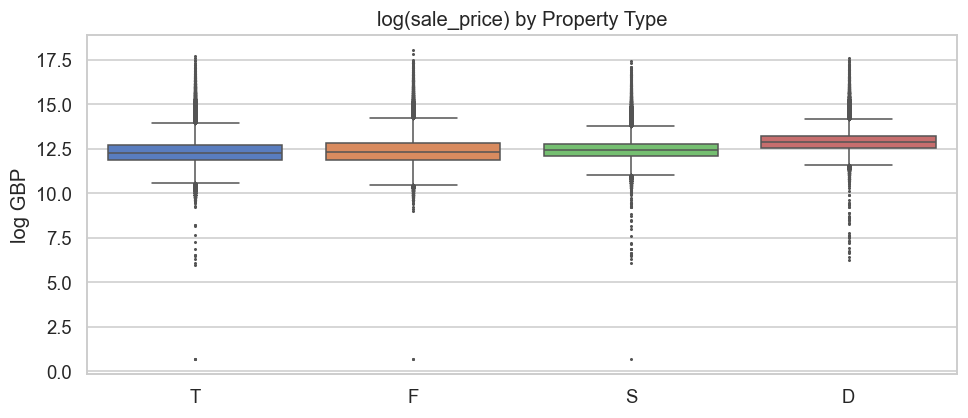

In [15]:
# 3.7 Box-plot: log price by property type
tmp = df[["property_type","sale_price"]].dropna().copy()
tmp["log_price"] = np.log1p(tmp["sale_price"])
order = tmp.groupby("property_type")["log_price"].median().sort_values().index
fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=tmp, x="property_type", y="log_price", order=order,
            palette="muted", ax=ax, fliersize=1)
ax.set_title("log(sale_price) by Property Type")
ax.set_xlabel(""); ax.set_ylabel("log GBP")
del tmp; plt.tight_layout(); plt.show()


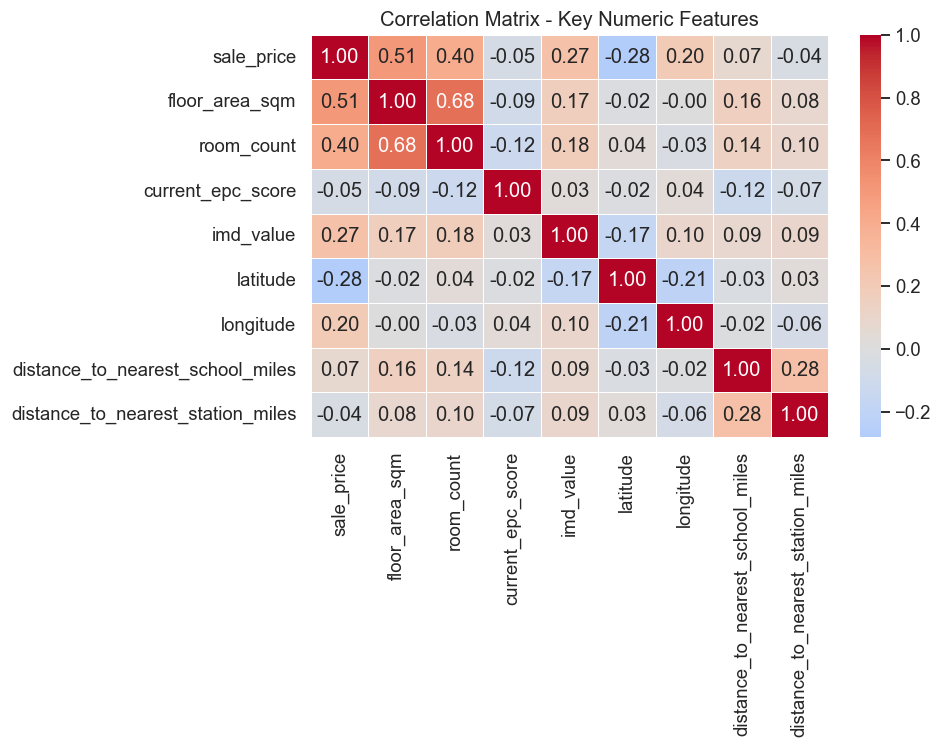

In [16]:
# 3.8 Correlation heatmap
corr_cols = ["sale_price","floor_area_sqm","room_count",
             "current_epc_score","imd_value","latitude","longitude",
             "distance_to_nearest_school_miles",
             "distance_to_nearest_station_miles"]
corr_cols = [c for c in corr_cols if c in df.columns]
corr = df[corr_cols].dropna().corr()
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, ax=ax, linewidths=0.5)
ax.set_title("Correlation Matrix - Key Numeric Features")
plt.tight_layout(); plt.show()


## 4  Data Cleaning

### Critical ordering
1. **String sentinel replacement FIRST** -- replace NO DATA! and INVALID! with Unknown *before* dropna(). If dropped first, those strings would survive as fake data.
2. **Drop rows** missing genuinely required columns.
3. **Extract temporal features** (sale_year, sale_month) from sale_date.
4. **Log-transform** the target.


In [17]:
# 4.1 String sentinel replacement (MUST run before dropna)
SENTINELS = ["NO DATA!", "INVALID!", "no data", "invalid", "NO DATA", "INVALID"]
for col in ["construction_age_band"]:
    if col not in df.columns: continue
    n_rep = df[col].isin(SENTINELS).sum()
    df[col] = df[col].replace({s: "Unknown" for s in SENTINELS})
    mask = df[col].astype(str).str.strip().str.lower() == "unknown"
    df.loc[mask, col] = "Unknown"
    print(f"{col}: replaced {n_rep:,} sentinels with Unknown")


construction_age_band: replaced 649,363 sentinels with Unknown


In [18]:
# 4.2 Drop rows missing required columns
REQUIRED = ["sale_price","floor_area_sqm","property_type",
            "tenure_type","construction_age_band",
            "region_code","local_authority_code",
            "postcode_district","latitude","longitude","imd_value"]
REQUIRED = [c for c in REQUIRED if c in df.columns]
n_before = len(df)
df.dropna(subset=REQUIRED, inplace=True)
df.reset_index(drop=True, inplace=True)
n_drop = n_before - len(df)
print(f"Rows before: {n_before:,}")
print(f"Rows after : {len(df):,}  (dropped {n_drop:,} = {n_drop/n_before*100:.2f}%)")


Rows before: 5,019,426
Rows after : 4,947,690  (dropped 71,736 = 1.43%)


In [19]:
# 4.3 Extract temporal features
if "sale_date" in df.columns:
    df["sale_date"] = pd.to_datetime(df["sale_date"], errors="coerce")
    df["sale_year"]  = df["sale_date"].dt.year
    df["sale_month"] = df["sale_date"].dt.month
elif "sale_year" not in df.columns:
    raise ValueError("No sale_date or sale_year column found!")
if "sale_month" not in df.columns:
    df["sale_month"] = 1
df["sale_year"]  = df["sale_year"].fillna(0).astype(int)
df["sale_month"] = df["sale_month"].fillna(1).astype(int)
print("sale_year :", df["sale_year"].min(), "-", df["sale_year"].max())
print("sale_month:", df["sale_month"].min(), "-", df["sale_month"].max())


sale_year : 2018 - 2024
sale_month: 1 - 12


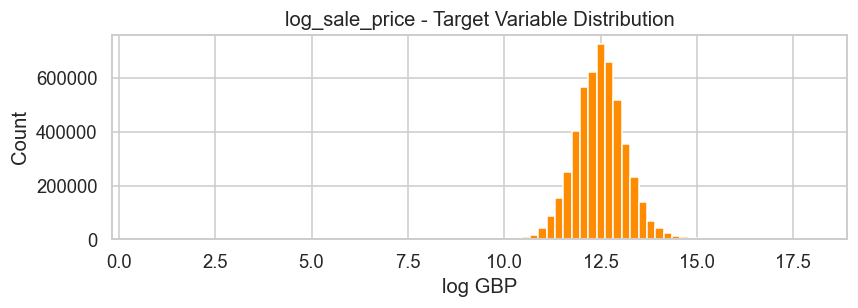

log_sale_price:
count   4,947,690.00
mean           12.50
std             0.65
min             0.69
25%            12.07
50%            12.50
75%            12.90
max            18.04


In [20]:
# 4.4 Log-transform target
df[TARGET_COL] = np.log1p(df["sale_price"])
fig, ax = plt.subplots(figsize=(8, 3))
ax.hist(df[TARGET_COL], bins=80, color="darkorange", edgecolor="white")
ax.set_title("log_sale_price - Target Variable Distribution")
ax.set_xlabel("log GBP"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()
print("log_sale_price:")
print(df[TARGET_COL].describe().round(4).to_string())

## 5  Feature Engineering

### 5.1  Room Count Imputation
 is missing for ~13% of rows. We train a  on observed rows
using ,  (temp-encoded), and  (temp proxy).
Predictions are rounded and clipped to [1, 15]. A binary  flag is inserted
immediately after .

### 5.2  Construction Age Band
Raw values include EPC standard strings, legacy formats, raw year integers, and sentinels.
The  function maps all variants to a chronological ordinal 0-12 (Unknown=12).


In [21]:
# 5.1a Temporary codes for imputation tree
_le_pt = LabelEncoder().fit(df["property_type"].astype(str))
df["_pt_tmp"]  = _le_pt.transform(df["property_type"].astype(str))
df["_cab_tmp"] = df["construction_age_band"].apply(
    lambda x: 12 if str(x).strip() == "Unknown" else 6)
TREE_FEATS = ["floor_area_sqm", "_pt_tmp", "_cab_tmp"]
mask_known = df["room_count"].notna()
mask_miss  = df["room_count"].isna()
print(f"Known: {mask_known.sum():,}  |  Missing: {mask_miss.sum():,}")


Known: 4,046,687  |  Missing: 901,003


In [22]:
# 5.1b Fit Decision Tree and predict missing room_count
X_imp = df.loc[mask_known, TREE_FEATS].values
y_imp = df.loc[mask_known, "room_count"].values
imputer_tree = DecisionTreeRegressor(max_depth=10, min_samples_leaf=50, random_state=42)
imputer_tree.fit(X_imp, y_imp)
preds = imputer_tree.predict(df.loc[mask_miss, TREE_FEATS].values)
preds = np.clip(np.round(preds), 1, 15).astype(int)
df.loc[mask_miss, "room_count"] = preds
print(f"Imputed {mask_miss.sum():,} values")
print(f"room_count range: {int(df.room_count.min())} - {int(df.room_count.max())}")


Imputed 901,003 values
room_count range: 1 - 99


In [23]:
# 5.1c Imputation flag and cleanup
insert_pos = df.columns.get_loc("room_count") + 1
df.insert(insert_pos, "room_count_was_imputed", mask_miss.astype(int))
df.drop(columns=["_pt_tmp", "_cab_tmp"], inplace=True, errors="ignore")
print("room_count_was_imputed distribution:")
vc = df["room_count_was_imputed"].value_counts()
print(f"  0 (original) : {vc.get(0,0):,}")
print(f"  1 (imputed)  : {vc.get(1,0):,}")


room_count_was_imputed distribution:
  0 (original) : 4,046,687
  1 (imputed)  : 901,003


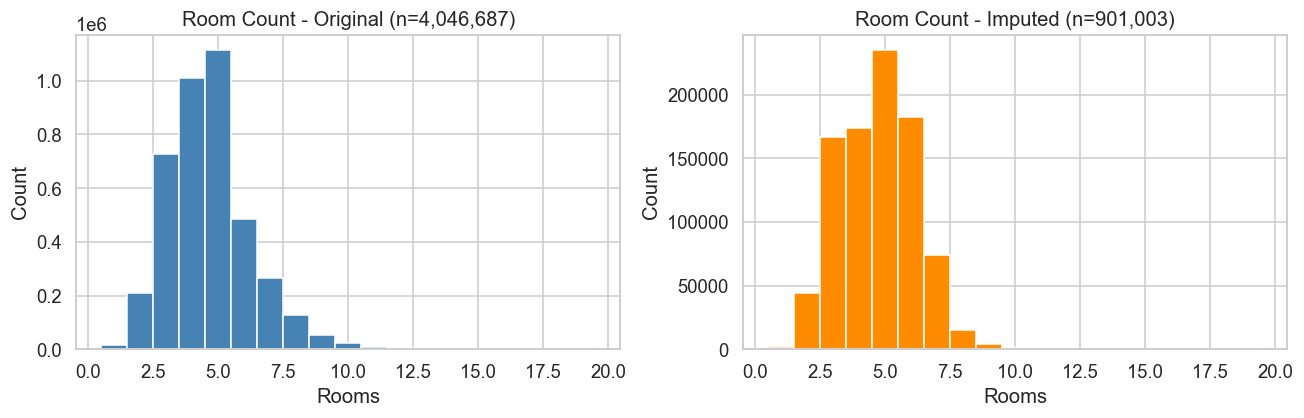

In [24]:
# 5.1d Verify: room count distribution by imputed flag
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, flag, col in zip(axes, [0, 1], ["steelblue", "darkorange"]):
    data = df.loc[df["room_count_was_imputed"]==flag, "room_count"]
    label = "Original" if flag==0 else "Imputed"
    ax.hist(data, bins=range(1, 21), color=col, edgecolor="white", align="left")
    ax.set_title(f"Room Count - {label} (n={len(data):,})")
    ax.set_xlabel("Rooms"); ax.set_ylabel("Count")
plt.tight_layout(); plt.show()


In [25]:
AGE_BAND_ORDER = {
    "England and Wales: before 1900":0,"England and Wales: 1900-1929":1,
    "England and Wales: 1930-1949":2,"England and Wales: 1950-1966":3,
    "England and Wales: 1967-1975":4,"England and Wales: 1976-1982":5,
    "England and Wales: 1983-1990":6,"England and Wales: 1991-1995":7,
    "England and Wales: 1996-2002":8,"England and Wales: 2003-2006":9,
    "England and Wales: 2007-2011":10,"England and Wales: 2012 onwards":11,
    "England and Wales: 2007 onwards":10,"Unknown":12,
}
def map_age_band(val):
    if val in AGE_BAND_ORDER: return AGE_BAND_ORDER[val]
    try:
        yr = int(str(val).strip())
        for threshold, code in [(1900,0),(1929,1),(1949,2),(1966,3),(1975,4),
                                 (1982,5),(1990,6),(1995,7),(2002,8),(2006,9),
                                 (2011,10),(2025,11)]:
            if yr <= threshold: return code
        return 12
    except (ValueError, TypeError): return 12
df["construction_age_band"] = df["construction_age_band"].map(map_age_band)
assert df["construction_age_band"].isna().sum() == 0, "NaN after age mapping!"
print("Age band distribution:", df["construction_age_band"].value_counts().sort_index().to_string())


Age band distribution: construction_age_band
0     418953
1     586963
2     602300
3     668670
4     504781
5     245223
6     305429
7     159935
8     236084
9     191472
10    112956
11    265557
12    649367


## 6  Outlier Analysis and Handling

**Rule:** outlier rows < 0.1% of dataset -> DROP; >= 0.1% -> CLIP.

| Column | Anomaly | Action |
|--------|---------|--------|
| floor_area_sqm | < 10 or > 480 sqm | Clip [10, 480] |
| room_count | > 20 | Drop |
| current_epc_score | > 150 | Drop |


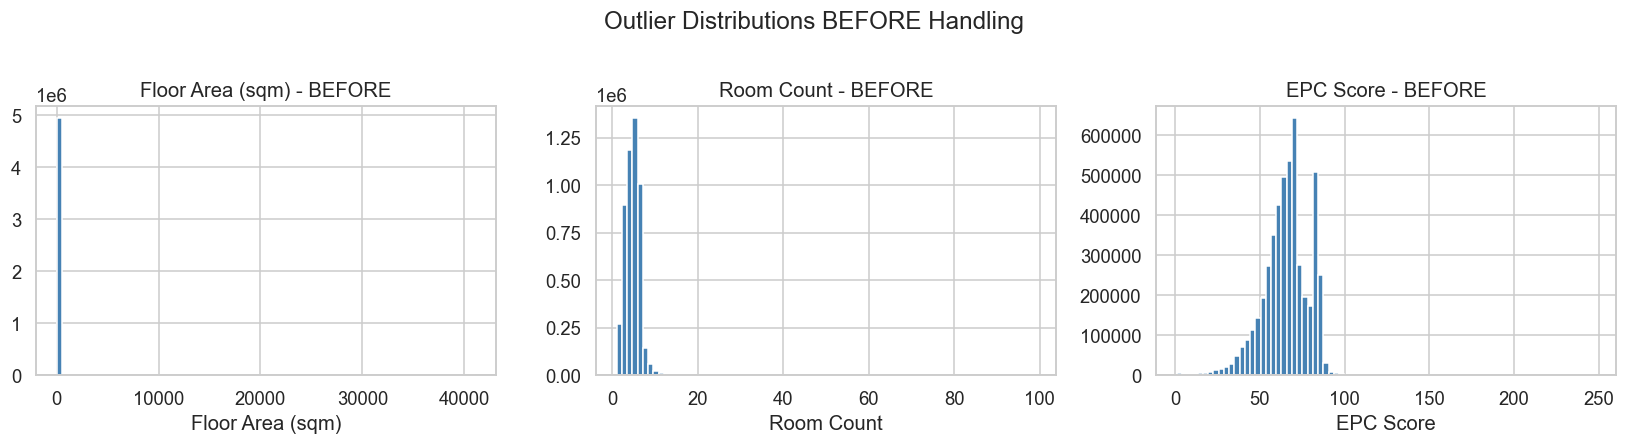

In [26]:
# 6.1 Distributions BEFORE
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, lbl in zip(axes,["floor_area_sqm","room_count","current_epc_score"],["Floor Area (sqm)","Room Count","EPC Score"]):
    if col in df.columns:
        ax.hist(df[col].dropna(), bins=80, color="steelblue", edgecolor="white")
    ax.set_title(f"{lbl} - BEFORE"); ax.set_xlabel(lbl)
plt.suptitle("Outlier Distributions BEFORE Handling", y=1.01)
plt.tight_layout(); plt.show()


In [27]:
# 6.2 Count outliers and decide
n = len(df); threshold = 0.1
checks = [("floor_area < 10",(df["floor_area_sqm"]<10).sum()),("floor_area > 480",(df["floor_area_sqm"]>480).sum()),("room_count > 20",(df["room_count"]>20).sum())]
if "current_epc_score" in df.columns:
    checks.append(("epc_score > 150",(df["current_epc_score"].fillna(0)>150).sum()))
for label, cnt in checks:
    pct = cnt/n*100
    action = "CLIP" if pct >= threshold else "DROP"
    print(f"{label:<25s}: {cnt:>7,} ({pct:.3f}%) -> {action}")


floor_area < 10          :   1,514 (0.031%) -> DROP
floor_area > 480         :   4,797 (0.097%) -> DROP
room_count > 20          :     367 (0.007%) -> DROP
epc_score > 150          :       6 (0.000%) -> DROP


In [28]:
# 6.3 Apply handling
n_before = len(df)
df["floor_area_sqm"] = df["floor_area_sqm"].clip(10, 480)
df = df[df["room_count"] <= 20].reset_index(drop=True)
if "current_epc_score" in df.columns:
    bad = df["current_epc_score"].notna() & (df["current_epc_score"] > 150)
    df = df[~bad].reset_index(drop=True)
print(f"Rows before: {n_before:,}")
print(f"Rows after : {len(df):,}  (removed {n_before-len(df):,})")


Rows before: 4,947,690
Rows after : 4,947,317  (removed 373)


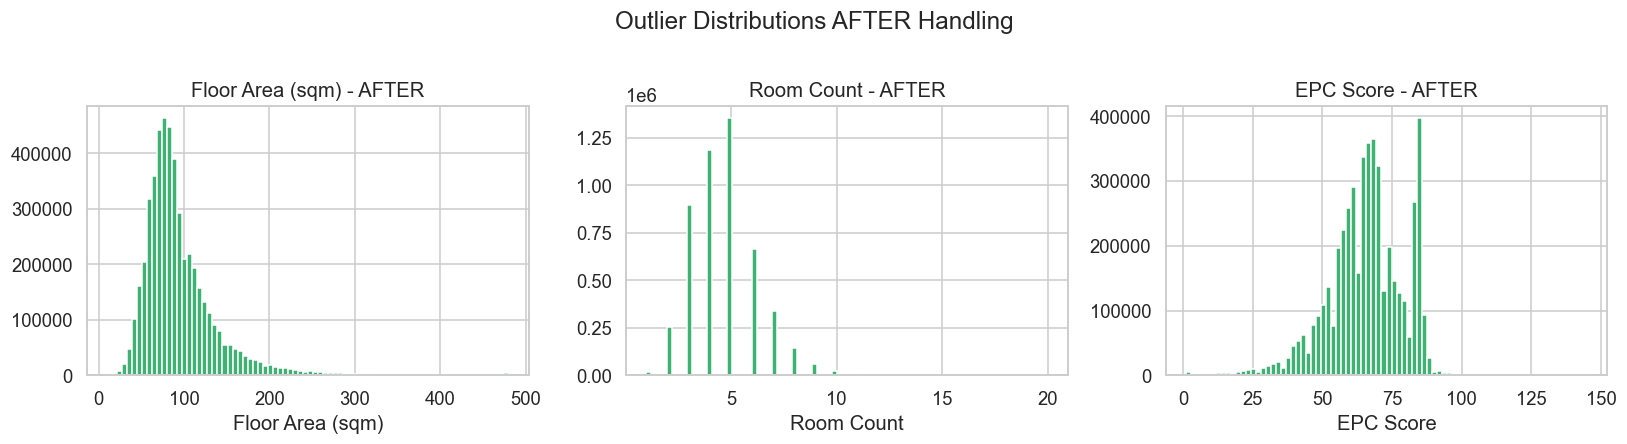

In [29]:
# 6.4 Distributions AFTER
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, lbl in zip(axes,["floor_area_sqm","room_count","current_epc_score"],["Floor Area (sqm)","Room Count","EPC Score"]):
    if col in df.columns:
        ax.hist(df[col].dropna(), bins=80, color="mediumseagreen", edgecolor="white")
    ax.set_title(f"{lbl} - AFTER"); ax.set_xlabel(lbl)
plt.suptitle("Outlier Distributions AFTER Handling", y=1.01)
plt.tight_layout(); plt.show()


## 7  Feature Encoding

All categorical columns are **label-encoded** to contiguous integers (0, 1, 2...).
This is needed for both LightGBM (native categorical split) and PyTorch (embedding lookup).

-  already has ordinal integers from the mapping step.
-  is converted to 0-indexed (0-11) for the embedding layer.
- Label encoders stored in a dict for inference reproducibility.


In [30]:
# 7.1 Label-encode nominal categoricals
CAT_TO_ENCODE = ["property_type","tenure_type","region_code",
                 "local_authority_code","postcode_district"]
label_encoders = {}
for col in CAT_TO_ENCODE:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le
    print(f"{col:<35s}: {len(le.classes_)} classes (0 - {len(le.classes_)-1})")


property_type                      : 4 classes (0 - 3)
tenure_type                        : 2 classes (0 - 1)
region_code                        : 9 classes (0 - 8)
local_authority_code               : 296 classes (0 - 295)
postcode_district                  : 2097 classes (0 - 2096)


In [31]:
# sale_month: 1-12 -> 0-11 (0-indexed for embedding lookup)
df["sale_month"] = (df["sale_month"] - 1).astype(int)
df["construction_age_band"] = df["construction_age_band"].astype(int)
# Sanity check: all FEATURE_COLS must be numeric
issues = []
for col in FEATURE_COLS:
    if col not in df.columns:
        issues.append(f"MISSING: {col}")
    elif not np.issubdtype(df[col].dtype, np.number):
        issues.append(f"NOT NUMERIC: {col} [{df[col].dtype}]")
if issues:
    for i in issues: print(i)
else:
    print(f"All {len(FEATURE_COLS)} feature columns present and numeric")


All 21 feature columns present and numeric


In [32]:
# 7.2 Cardinality table (for embedding config)
print(f"Column                               max_idx  n_unique")
print("-" * 55)
for col in CATEGORICAL_COLS:
    print(f"{col:<35s} {int(df[col].max()):>7d}  {df[col].nunique():>8d}")


Column                               max_idx  n_unique
-------------------------------------------------------
property_type                             3         4
tenure_type                               1         2
construction_age_band                    12        13
region_code                               8         9
local_authority_code                    295       296
postcode_district                      2096      2097
sale_month                               11        12


## 8  Train / Val / Test Split - Time-Based

No random shuffling. Shuffling leaks future price information into training.

| Split | Years | Role |
|-------|-------|------|
| **Train** | <= 2021 | Model learns price patterns |
| **Val** | 2022 | Hyper-parameter tuning / early stopping |
| **Test** | >= 2023 | Final unbiased evaluation |


In [33]:
# 8.1 Temporal split
df_train = df[df["sale_year"] <= 2021].reset_index(drop=True)
df_val   = df[df["sale_year"] == 2022].reset_index(drop=True)
df_test  = df[df["sale_year"] >= 2023].reset_index(drop=True)
print(f"Train: {len(df_train):>8,}  ({len(df_train)/len(df)*100:.1f}%)")
print(f"Val  : {len(df_val):>8,}  ({len(df_val)/len(df)*100:.1f}%)")
print(f"Test : {len(df_test):>8,}  ({len(df_test)/len(df)*100:.1f}%)")


Train: 3,176,101  (64.2%)
Val  :  817,330  (16.5%)
Test :  953,886  (19.3%)


In [34]:
# 8.2 Feature/target arrays
X_train, y_train = df_train[FEATURE_COLS], df_train[TARGET_COL]
X_val,   y_val   = df_val[FEATURE_COLS],   df_val[TARGET_COL]
X_test,  y_test  = df_test[FEATURE_COLS],  df_test[TARGET_COL]
price_train = df_train["sale_price"]
price_val   = df_val["sale_price"]
price_test  = df_test["sale_price"]
print("X_train:", X_train.shape, "| X_val:", X_val.shape, "| X_test:", X_test.shape)


X_train: (3176101, 21) | X_val: (817330, 21) | X_test: (953886, 21)


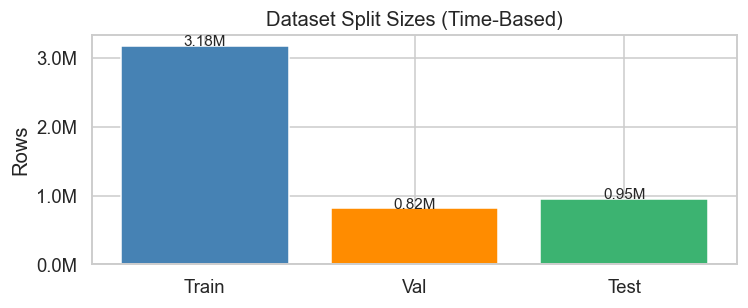

In [35]:
# 8.3 Split size chart
sizes = {"Train": len(df_train), "Val": len(df_val), "Test": len(df_test)}
fig, ax = plt.subplots(figsize=(7, 3))
bars = ax.bar(sizes.keys(), sizes.values(),
              color=["steelblue","darkorange","mediumseagreen"], edgecolor="white")
ax.set_title("Dataset Split Sizes (Time-Based)")
ax.set_ylabel("Rows")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f"{x/1e6:.1f}M"))
for b in bars:
    h = b.get_height()
    ax.text(b.get_x()+b.get_width()/2, h+500, f"{h/1e6:.2f}M", ha="center", fontsize=10)
plt.tight_layout(); plt.show()


## 9  LightGBM Benchmark

LightGBM histogram-based gradient boosting. Key choices:
-  passed explicitly -- native optimal-split, not ordered integers.
- 3000 rounds with early_stopping(100) on validation RMSE.
-  -- complex boundaries, controlled overfitting.


In [36]:
# 9.1 LightGBM Dataset objects
cat_indices = [FEATURE_COLS.index(c) for c in CATEGORICAL_COLS]
lgb_ds_tr = lgb.Dataset(X_train, label=y_train,
    categorical_feature=cat_indices, free_raw_data=False)
lgb_ds_va = lgb.Dataset(X_val, label=y_val, reference=lgb_ds_tr,
    categorical_feature=cat_indices, free_raw_data=False)
print("LightGBM datasets ready")
print(f"Categorical feature indices: {cat_indices}")


LightGBM datasets ready
Categorical feature indices: [14, 15, 16, 17, 18, 19, 20]


In [37]:
# 9.2 Hyperparameters
lgb_params = {
    "objective"        : "regression",
    "metric"           : "rmse",
    "learning_rate"    : 0.05,
    "num_leaves"       : 127,
    "min_child_samples": 20,
    "feature_fraction" : 0.8,
    "bagging_fraction" : 0.8,
    "bagging_freq"     : 5,
    "reg_alpha"        : 0.1,
    "reg_lambda"       : 0.1,
    "n_jobs"           : -1,
    "seed"             : 42,
    "verbose"          : -1,
}
print("LightGBM params ready")


LightGBM params ready


In [38]:
# 9.3 Train (3000 rounds, ~5-20 min on CPU)
lgb_evals = {}
t0 = time.time()
lgb_model = lgb.train(
    lgb_params, lgb_ds_tr,
    num_boost_round=3000,
    valid_sets=[lgb_ds_tr, lgb_ds_va],
    valid_names=["train", "val"],
    callbacks=[
        lgb.early_stopping(stopping_rounds=100, verbose=True),
        lgb.log_evaluation(period=100),
        lgb.record_evaluation(lgb_evals),
    ],
)
print(f"Training: {(time.time()-t0)/60:.1f} min | Best iter: {lgb_model.best_iteration}")


Training until validation scores don't improve for 100 rounds
[100]	train's rmse: 0.202627	val's rmse: 0.253282
[200]	train's rmse: 0.191129	val's rmse: 0.242443
[300]	train's rmse: 0.186431	val's rmse: 0.239105
[400]	train's rmse: 0.183384	val's rmse: 0.236819
[500]	train's rmse: 0.18156	val's rmse: 0.235787
[600]	train's rmse: 0.180129	val's rmse: 0.234813
[700]	train's rmse: 0.178841	val's rmse: 0.233986
[800]	train's rmse: 0.177775	val's rmse: 0.233416
[900]	train's rmse: 0.17679	val's rmse: 0.232833
[1000]	train's rmse: 0.175974	val's rmse: 0.232363
[1100]	train's rmse: 0.17516	val's rmse: 0.232016
[1200]	train's rmse: 0.174415	val's rmse: 0.231735
[1300]	train's rmse: 0.173663	val's rmse: 0.231328
[1400]	train's rmse: 0.172992	val's rmse: 0.230869
[1500]	train's rmse: 0.172316	val's rmse: 0.230617
[1600]	train's rmse: 0.171714	val's rmse: 0.230245
[1700]	train's rmse: 0.171132	val's rmse: 0.230015
[1800]	train's rmse: 0.170553	val's rmse: 0.229798
[1900]	train's rmse: 0.170012	va

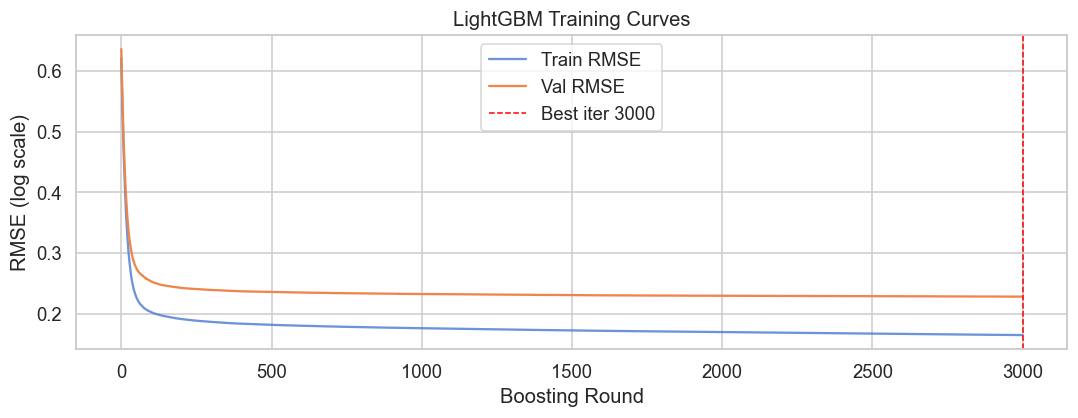

In [45]:
# 9.4 Training curves
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(lgb_evals["train"]["rmse"], label="Train RMSE", lw=1.5, alpha=0.8)
ax.plot(lgb_evals["val"]["rmse"],   label="Val RMSE",   lw=1.5)
ax.axvline(lgb_model.best_iteration, color="red", ls="--", lw=1,
           label=f"Best iter {lgb_model.best_iteration}")
ax.set_xlabel("Boosting Round")
ax.set_ylabel("RMSE (log scale)")
ax.set_title("LightGBM Training Curves")
ax.legend(); plt.tight_layout(); plt.show()


In [46]:
# 9.5 Shared evaluation function
def evaluate_predictions(y_pred_log, y_true_log, price_true, split_name):
    pp = np.expm1(y_pred_log); pr = price_true.values
    rmse = float(np.sqrt(np.mean((y_pred_log - y_true_log.values)**2)))
    mae  = float(np.mean(np.abs(pp - pr)))
    mape = float(np.median(np.abs(pp - pr) / pr) * 100)
    w10  = float((np.abs(pp - pr)/pr <= 0.10).mean() * 100)
    w20  = float((np.abs(pp - pr)/pr <= 0.20).mean() * 100)
    print(f"[{split_name}] RMSE(log)={rmse:.4f} | MAE=GBP{mae:,.0f} | MedAPE={mape:.2f}% | W10%={w10:.1f}% | W20%={w20:.1f}%")
    return dict(split=split_name, rmse_log=rmse, mae_gbp=mae, med_ape=mape, within_10=w10, within_20=w20)


In [47]:
# 9.6 Evaluate LightGBM
lgb_pred_val  = lgb_model.predict(X_val,  num_iteration=lgb_model.best_iteration)
lgb_pred_test = lgb_model.predict(X_test, num_iteration=lgb_model.best_iteration)
lgb_res_val  = evaluate_predictions(lgb_pred_val,  y_val,  price_val,  "LGB Val")
lgb_res_test = evaluate_predictions(lgb_pred_test, y_test, price_test, "LGB Test")


[LGB Val] RMSE(log)=0.2281 | MAE=GBP63,379 | MedAPE=13.63% | W10%=36.0% | W20%=70.7%
[LGB Test] RMSE(log)=0.2403 | MAE=GBP65,342 | MedAPE=14.75% | W10%=33.1% | W20%=66.8%


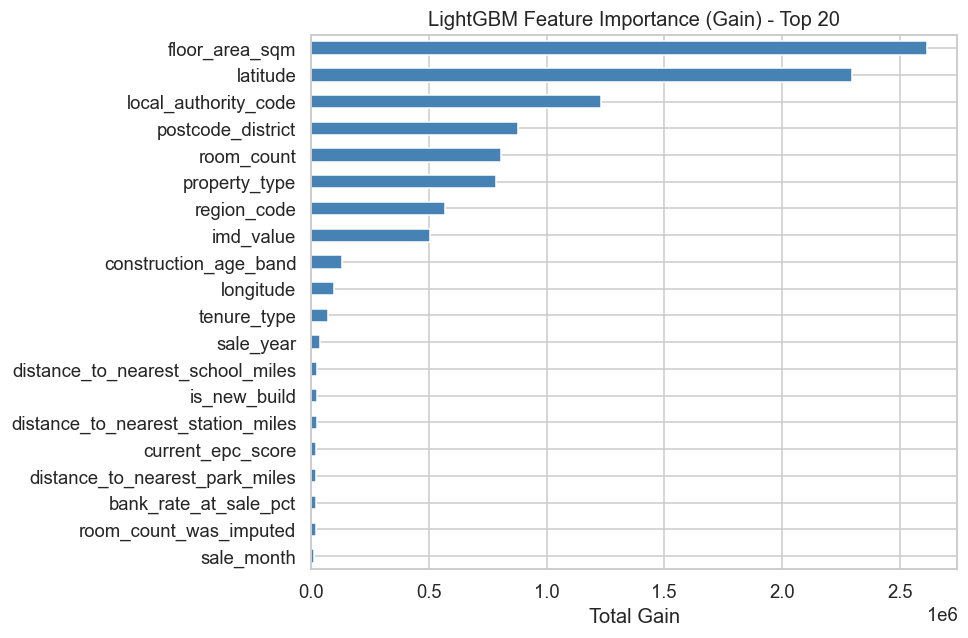

In [48]:
# 9.7 Feature importance - top 20
fi = pd.Series(lgb_model.feature_importance("gain"), index=FEATURE_COLS
              ).sort_values(ascending=False).head(20)
fig, ax = plt.subplots(figsize=(9, 6))
fi.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.invert_yaxis()
ax.set_title("LightGBM Feature Importance (Gain) - Top 20")
ax.set_xlabel("Total Gain")
plt.tight_layout(); plt.show()


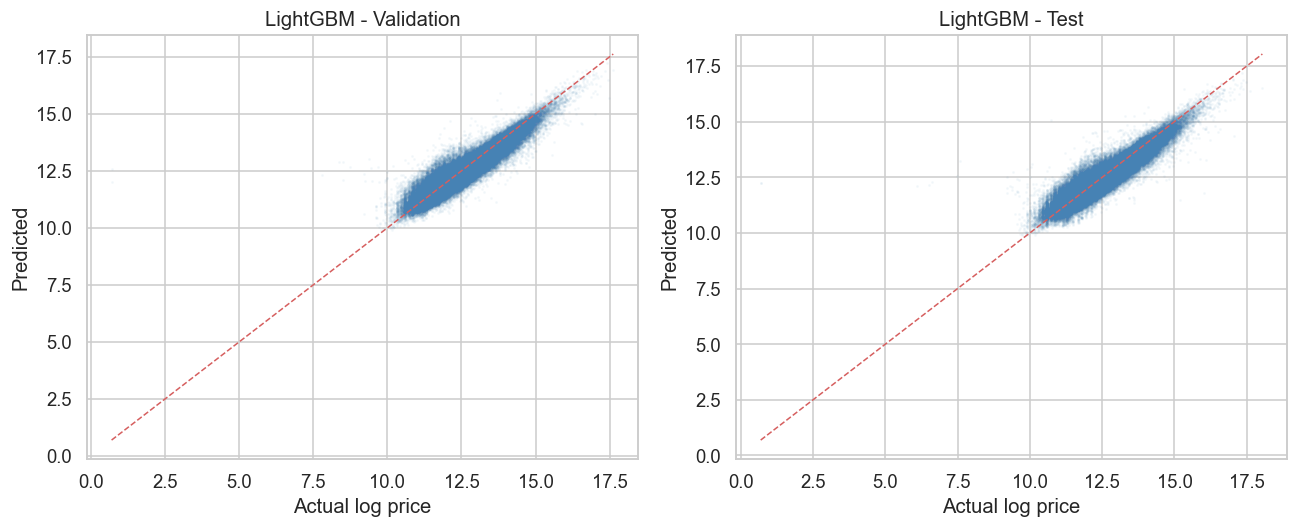

In [49]:
# 9.8 Predicted vs Actual scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, yt, title in zip(axes,[lgb_pred_val,lgb_pred_test],[y_val.values,y_test.values],["Validation","Test"]):
    ax.scatter(yt, yp, alpha=0.04, s=1, color="steelblue")
    lims = [min(yt.min(),yp.min()), max(yt.max(),yp.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_title(f"LightGBM - {title}")
    ax.set_xlabel("Actual log price"); ax.set_ylabel("Predicted")
plt.tight_layout(); plt.show()


In [50]:
# 9.9 Save LightGBM artefacts
lgb_path = os.path.join(MODEL_LGB, "lgb_property_model.txt")
le_path  = os.path.join(MODEL_LGB, "label_encoders.pkl")
lgb_model.save_model(lgb_path)
joblib.dump(label_encoders, le_path)
print(f"LightGBM model -> {lgb_path}")
print(f"Label encoders -> {le_path}")
print("Files:", os.listdir(MODEL_LGB))


LightGBM model -> C:\shared\LSBU\sse\SSE - CW2 - 10 April 2026\ml-dl\model_lgb\lgb_property_model.txt
Label encoders -> C:\shared\LSBU\sse\SSE - CW2 - 10 April 2026\ml-dl\model_lgb\label_encoders.pkl
Files: ['label_encoders.pkl', 'lgb_property_model.txt']


## 10  Deep Learning - Entity Embeddings (PyTorch)

Entity embeddings learn a **dense vector** for each categorical value.
High-cardinality features like postcode district benefit most.

**Architecture:**
Embedding layers -> flatten -> concat with scaled numerics -> BN+ReLU+Dropout (512->256->128) -> Linear(1)

Input dim ~ 125 (embeddings) + 14 (numeric) = 139
Parameters: ~357,715


In [51]:
# 10.1 StandardScaler for numeric features (fit on train only)
scaler   = StandardScaler()
X_tr_num = scaler.fit_transform(X_train[NUMERIC_COLS].fillna(0).astype(float))
X_va_num = scaler.transform(X_val[NUMERIC_COLS].fillna(0).astype(float))
X_te_num = scaler.transform(X_test[NUMERIC_COLS].fillna(0).astype(float))
X_tr_cat = X_train[CATEGORICAL_COLS].values.astype(np.int64)
X_va_cat = X_val[CATEGORICAL_COLS].values.astype(np.int64)
X_te_cat = X_test[CATEGORICAL_COLS].values.astype(np.int64)
joblib.dump(scaler, os.path.join(MODEL_DL, "scaler.pkl"))
print("Scaler fitted on train and saved")


Scaler fitted on train and saved


In [53]:
# 10.2 Embedding configurations
def emb_dim(n): return min(50, max(2, (n + 1) // 2))
EMB_CONFIGS = []
for col in CATEGORICAL_COLS:
    n_cats = int(df[col].max()) + 1
    dim    = emb_dim(n_cats)
    EMB_CONFIGS.append((col, n_cats, dim))
    print(f"  {col:<35s}  n_cats={n_cats:>5d}  emb_dim={dim}")
total_emb = sum(e[2] for e in EMB_CONFIGS)
print(f"Embedding total: {total_emb} | Numeric: {len(NUMERIC_COLS)} | Network input: {total_emb+len(NUMERIC_COLS)}")


  property_type                        n_cats=    4  emb_dim=2
  tenure_type                          n_cats=    2  emb_dim=2
  construction_age_band                n_cats=   13  emb_dim=7
  region_code                          n_cats=    9  emb_dim=5
  local_authority_code                 n_cats=  296  emb_dim=50
  postcode_district                    n_cats= 2097  emb_dim=50
  sale_month                           n_cats=   12  emb_dim=6
Embedding total: 122 | Numeric: 14 | Network input: 136


In [54]:
# 10.3 PropertyPriceNet model class
class PropertyPriceNet(nn.Module):
    def __init__(self, emb_configs, n_numeric, hidden_dims=(512,256,128), dropout=0.3):
        super().__init__()
        self.embeddings = nn.ModuleList([
            nn.Embedding(n_cats, edim) for _, n_cats, edim in emb_configs])
        for e in self.embeddings: nn.init.uniform_(e.weight, -0.05, 0.05)
        in_dim = sum(e[2] for e in emb_configs) + n_numeric
        layers, prev = [], in_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev,h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev = h
        layers.append(nn.Linear(prev, 1))
        self.net = nn.Sequential(*layers)
    def forward(self, x_cat, x_num):
        embs = [self.embeddings[i](x_cat[:,i]) for i in range(len(self.embeddings))]
        return self.net(torch.cat(embs + [x_num], dim=1)).squeeze(1)
print("PropertyPriceNet defined")


PropertyPriceNet defined


In [55]:
# 10.4 PropertyDataset wrapper
class PropertyDataset(Dataset):
    def __init__(self, cat_arr, num_arr, tgt_arr):
        self.cat = torch.tensor(cat_arr, dtype=torch.long)
        self.num = torch.tensor(num_arr, dtype=torch.float32)
        self.tgt = torch.tensor(tgt_arr, dtype=torch.float32)
    def __len__(self):  return len(self.tgt)
    def __getitem__(self, idx): return self.cat[idx], self.num[idx], self.tgt[idx]
print("PropertyDataset defined")


PropertyDataset defined


In [59]:
# 10.5 DataLoaders
BATCH_SIZE = 4096; N_WORKERS = 0  # must be 0 on Windows in Jupyter

ds_tr = PropertyDataset(X_tr_cat, X_tr_num, y_train.values)
ds_va = PropertyDataset(X_va_cat, X_va_num, y_val.values)
ds_te = PropertyDataset(X_te_cat, X_te_num, y_test.values)

dl_tr = DataLoader(ds_tr, batch_size=BATCH_SIZE,   shuffle=True,
                   num_workers=0, pin_memory=True)
dl_va = DataLoader(ds_va, batch_size=BATCH_SIZE*2, shuffle=False,
                   num_workers=0, pin_memory=True)
dl_te = DataLoader(ds_te, batch_size=BATCH_SIZE*2, shuffle=False,
                   num_workers=0, pin_memory=True)
print(f"Train batches: {len(dl_tr)} | Val batches: {len(dl_va)}")

Train batches: 776 | Val batches: 100


In [71]:
# 10.6 Model, optimiser, scheduler
model = PropertyPriceNet(
    EMB_CONFIGS, n_numeric=len(NUMERIC_COLS),
    hidden_dims=(512, 256, 128), dropout=0.4
).to(DEVICE)

# Critical fix: initialise output bias to mean(y_train)
# Without this, epoch 1 predictions are near 0 while targets are ~12 -> MSE explodes
with torch.no_grad():
    model.net[-1].bias.fill_(float(y_train.mean()))

total_p = sum(p.numel() for p in model.parameters())
print(f"Trainable params : {total_p:,}")
print(f"Output bias init : {y_train.mean():.4f}  (mean log_sale_price)")

# Lower lr, stronger weight decay, more patience before reducing
optimiser = torch.optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimiser, mode="min", factor=0.5, patience=5, min_lr=1e-6)
criterion = nn.MSELoss()
print("Model ready on:", DEVICE)

Trainable params : 356,159
Output bias init : 12.4572  (mean log_sale_price)
Model ready on: cuda


In [72]:
# 10.7 Training loop
MAX_EPOCHS = 100
PATIENCE   = 15        # was 5 — gives model room to recover from plateaus
best_val_loss  = float("inf")
patience_cnt   = 0
history        = {"train": [], "val": []}
best_ckpt      = os.path.join(MODEL_DL, "best_model.pt")

for epoch in range(1, MAX_EPOCHS + 1):
    # ── Train
    model.train(); t_loss = 0.0
    for xc, xn, yb in dl_tr:
        xc, xn, yb = xc.to(DEVICE), xn.to(DEVICE), yb.to(DEVICE)
        optimiser.zero_grad()
        loss = criterion(model(xc, xn), yb)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # prevents explosions
        optimiser.step()
        t_loss += loss.item() * len(yb)
    t_loss /= len(ds_tr)
    # ── Validate
    model.eval(); v_loss = 0.0
    with torch.no_grad():
        for xc, xn, yb in dl_va:
            xc, xn, yb = xc.to(DEVICE), xn.to(DEVICE), yb.to(DEVICE)
            v_loss += criterion(model(xc, xn), yb).item() * len(yb)
    v_loss /= len(ds_va)
    scheduler.step(v_loss)
    history["train"].append(t_loss)
    history["val"].append(v_loss)
    lr = optimiser.param_groups[0]["lr"]
    print(f"Ep {epoch:02d} | train={t_loss:.5f} | val_rmse={math.sqrt(v_loss):.4f} | lr={lr:.2e}")
    if v_loss < best_val_loss - 1e-6:
        best_val_loss = v_loss; patience_cnt = 0
        torch.save(model.state_dict(), best_ckpt)
    else:
        patience_cnt += 1
        if patience_cnt >= PATIENCE:
            print(f"Early stopping at epoch {epoch}"); break

print(f"Training complete. Best val RMSE: {math.sqrt(best_val_loss):.4f}")

Ep 01 | train=0.08790 | val_rmse=0.4007 | lr=3.00e-04
Ep 02 | train=0.05657 | val_rmse=0.4544 | lr=3.00e-04
Ep 03 | train=0.05395 | val_rmse=0.4359 | lr=3.00e-04
Ep 04 | train=0.05199 | val_rmse=0.4190 | lr=3.00e-04
Ep 05 | train=0.05068 | val_rmse=0.3783 | lr=3.00e-04
Ep 06 | train=0.04959 | val_rmse=0.3175 | lr=3.00e-04
Ep 07 | train=0.04885 | val_rmse=0.2555 | lr=3.00e-04
Ep 08 | train=0.04831 | val_rmse=0.2322 | lr=3.00e-04
Ep 09 | train=0.04791 | val_rmse=0.2278 | lr=3.00e-04
Ep 10 | train=0.04751 | val_rmse=0.2311 | lr=3.00e-04
Ep 11 | train=0.04730 | val_rmse=0.2280 | lr=3.00e-04
Ep 12 | train=0.04709 | val_rmse=0.2237 | lr=3.00e-04
Ep 13 | train=0.04694 | val_rmse=0.2312 | lr=3.00e-04
Ep 14 | train=0.04677 | val_rmse=0.2206 | lr=3.00e-04
Ep 15 | train=0.04667 | val_rmse=0.2186 | lr=3.00e-04
Ep 16 | train=0.04661 | val_rmse=0.2183 | lr=3.00e-04
Ep 17 | train=0.04646 | val_rmse=0.2182 | lr=3.00e-04
Ep 18 | train=0.04636 | val_rmse=0.2251 | lr=3.00e-04
Ep 19 | train=0.04633 | val_

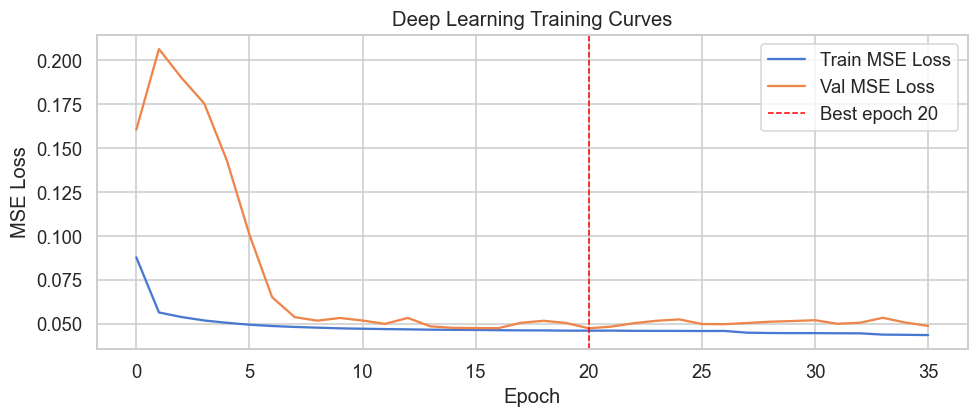

In [74]:
# 10.8 Load best weights and plot training curves
model.load_state_dict(torch.load(best_ckpt, map_location=DEVICE, weights_only=True))
model.eval()
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(history["train"], label="Train MSE Loss", lw=1.5)
ax.plot(history["val"],   label="Val MSE Loss",   lw=1.5)
best_ep = int(np.argmin(history["val"]))
ax.axvline(best_ep, color="red", ls="--", lw=1, label=f"Best epoch {best_ep}")
ax.set_title("Deep Learning Training Curves")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.legend(); plt.tight_layout(); plt.show()


In [75]:
# 10.9 Inference helper
def dl_predict(loader):
    preds = []; model.eval()
    with torch.no_grad():
        for xc, xn, _ in loader:
            xc, xn = xc.to(DEVICE), xn.to(DEVICE)
            preds.append(model(xc, xn).cpu().numpy())
    return np.concatenate(preds)
dl_pred_val  = dl_predict(dl_va)
dl_pred_test = dl_predict(dl_te)
print("Val predictions :", dl_pred_val.shape)
print("Test predictions:", dl_pred_test.shape)


Val predictions : (817330,)
Test predictions: (953886,)


In [82]:
# 10.10 Evaluate Deep Learning
dl_res_val  = evaluate_predictions(dl_pred_val,  y_val,  price_val,  "DL Val")
dl_res_test = evaluate_predictions(dl_pred_test, y_test, price_test, "DL Test")


[DL Val] RMSE(log)=0.2180 | MAE=GBP57,655 | MedAPE=11.13% | W10%=45.8% | W20%=74.3%
[DL Test] RMSE(log)=0.2490 | MAE=GBP68,032 | MedAPE=14.05% | W10%=37.0% | W20%=66.0%


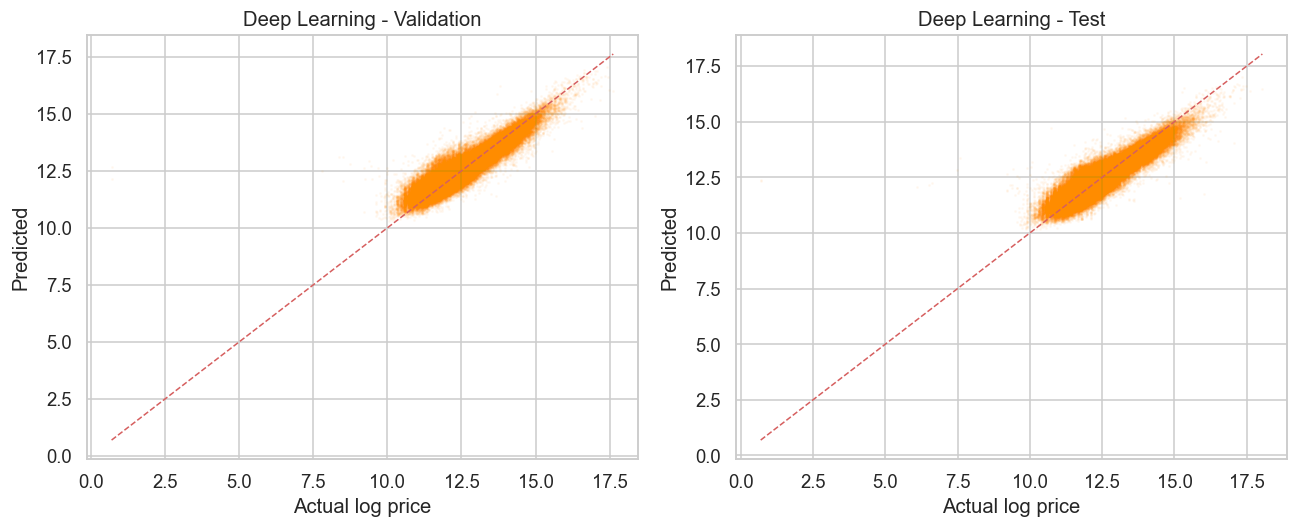

In [77]:
# 10.11 DL predicted vs actual scatter
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, yp, yt, title in zip(axes,[dl_pred_val,dl_pred_test],[y_val.values,y_test.values],["Validation","Test"]):
    ax.scatter(yt, yp, alpha=0.04, s=1, color="darkorange")
    lims = [min(yt.min(),yp.min()), max(yt.max(),yp.max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_title(f"Deep Learning - {title}")
    ax.set_xlabel("Actual log price"); ax.set_ylabel("Predicted")
plt.tight_layout(); plt.show()


In [78]:
# 10.12 Save all DL artefacts
torch.save({
    "model_state_dict": model.state_dict(),
    "emb_configs"     : EMB_CONFIGS,
    "n_numeric"       : len(NUMERIC_COLS),
    "numeric_cols"    : NUMERIC_COLS,
    "categorical_cols": CATEGORICAL_COLS,
    "hidden_dims"     : (512, 256, 128),
    "dropout"         : 0.3,
}, os.path.join(MODEL_DL, "full_checkpoint.pt"))
print("DL artefacts in", MODEL_DL)
for f in os.listdir(MODEL_DL): print(f"  {f}")


DL artefacts in C:\shared\LSBU\sse\SSE - CW2 - 10 April 2026\ml-dl\model_dl
  best_model.pt
  full_checkpoint.pt
  scaler.pkl


## 11  Model Comparison

Both models evaluated on the **test set (2023-2024)** -- completely unseen during training.


In [79]:
# 11.1 Metrics summary table
results = pd.DataFrame([lgb_res_val, lgb_res_test, dl_res_val, dl_res_test]).set_index("split")
results.columns = ["RMSE (log)","MAE (GBP)","Median APE %","Within 10%","Within 20%"]
print(results.to_string())


          RMSE (log)  MAE (GBP)  Median APE %  Within 10%  Within 20%
split                                                                
LGB Val         0.23  63,378.68         13.63       35.99       70.74
LGB Test        0.24  65,341.90         14.75       33.12       66.78
DL Val          0.22  57,655.47         11.13       45.79       74.26
DL Test         0.25  68,031.77         14.05       37.02       65.99


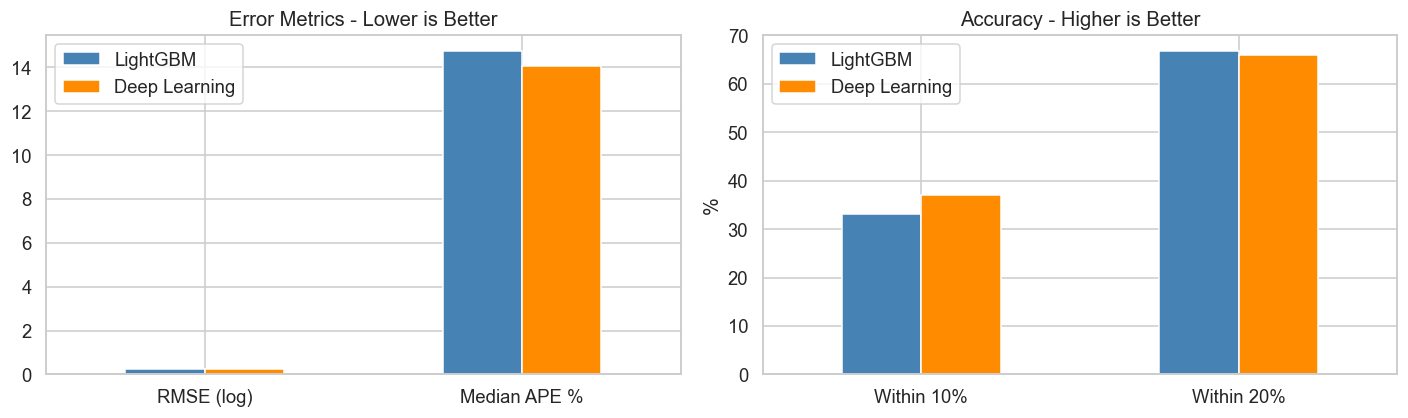

In [80]:
# 11.2 Side-by-side bar chart
compare = pd.DataFrame({
    "LightGBM"     : [lgb_res_test["rmse_log"],lgb_res_test["med_ape"],lgb_res_test["within_10"],lgb_res_test["within_20"]],
    "Deep Learning": [dl_res_test["rmse_log"], dl_res_test["med_ape"], dl_res_test["within_10"], dl_res_test["within_20"]]
}, index=["RMSE (log)","Median APE %","Within 10%","Within 20%"])
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
compare.iloc[:2].plot(kind="bar", ax=axes[0], rot=0, color=["steelblue","darkorange"], edgecolor="white")
axes[0].set_title("Error Metrics - Lower is Better")
compare.iloc[2:].plot(kind="bar", ax=axes[1], rot=0, color=["steelblue","darkorange"], edgecolor="white")
axes[1].set_title("Accuracy - Higher is Better")
axes[1].set_ylabel("%")
plt.tight_layout(); plt.show()


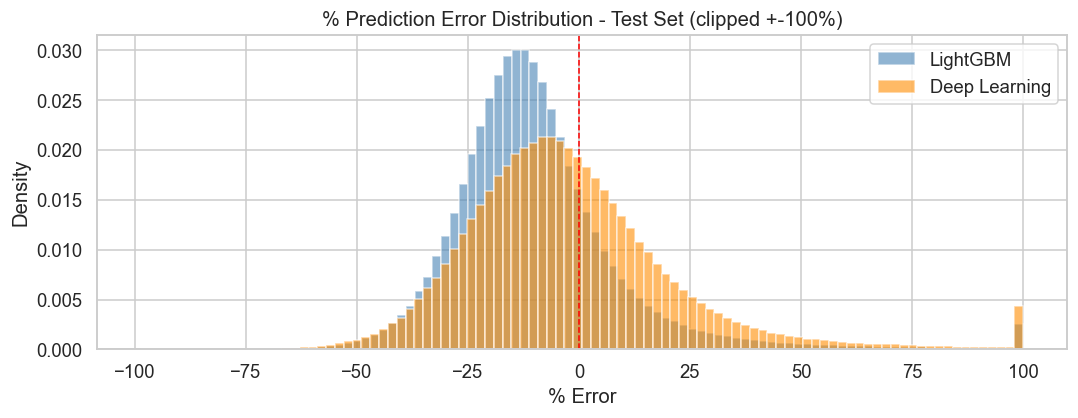

In [81]:
# 11.3 Error distribution
lgb_err = (np.expm1(lgb_pred_test)/price_test.values - 1)*100
dl_err  = (np.expm1(dl_pred_test) /price_test.values - 1)*100
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(lgb_err.clip(-100,100), bins=100, alpha=0.6, density=True, label="LightGBM", color="steelblue")
ax.hist(dl_err.clip(-100,100),  bins=100, alpha=0.6, density=True, label="Deep Learning", color="darkorange")
ax.axvline(0, color="red", lw=1, ls="--")
ax.set_title("% Prediction Error Distribution - Test Set (clipped +-100%)")
ax.set_xlabel("% Error"); ax.set_ylabel("Density")
ax.legend(); plt.tight_layout(); plt.show()


## 12  Summary

| | LightGBM | Deep Learning |
|---|---|---|
| Algorithm | Gradient Boosted Trees (3000 rounds) | Entity Embeddings + Dense Layers |
| Categorical handling | Native optimal-split | Learned dense embeddings |
| Training hardware | CPU (multi-core, n_jobs=-1) | GPU - RTX 4090 (CUDA) |
| Model file | model_lgb/lgb_property_model.txt | model_dl/full_checkpoint.pt |

### Key design decisions
- **Time-based split**: no random shuffling -- prevents future price leakage.
- **String sentinel cleanup before dropna**: prevents NO DATA! surviving as fake data.
- **Ordinal age band mapping**: robust function handles messy EPC string formats.
- **Room count imputation flag**: lets models account for uncertainty in imputed values.
- **StandardScaler on train only**: prevents test information leaking into scaling.
- **ReduceLROnPlateau without verbose=**: avoids PyTorch version compatibility error.
